In [216]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import yfinance as yfin

In [217]:
dataset = 'GS'  # we have data from the ticker
data = yfin.download(dataset, start="2020-01-01", end="2024-11-01")
n_components = 3  # Number of trends to analyze
if data.empty:
    raise ValueError(f"Data not found for {dataset}. Check ticker or date range.")
data = data[['Open', 'High', 'Low', 'Close']]

[*********************100%***********************]  1 of 1 completed


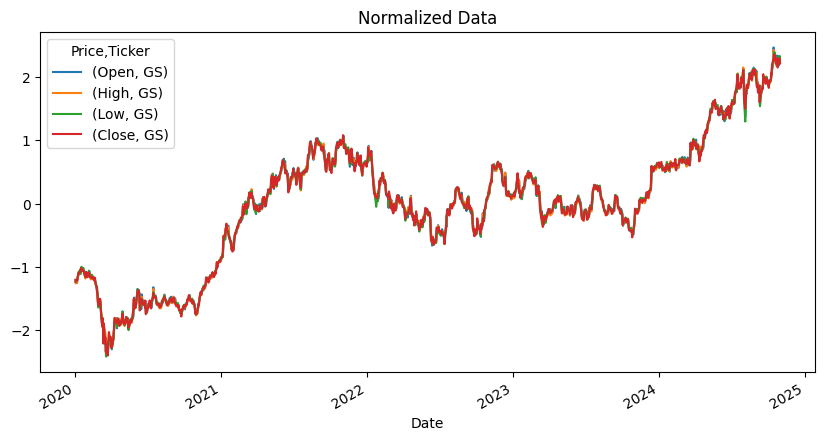

In [218]:
normalize = (data - data.mean()) / data.std()
normalize.plot(figsize=(10, 5), title="Normalized Data")
plt.show()

In [219]:
print("time-series matrix creation")
orignal = normalize.values.T
days = np.arange(orignal.shape[1])  # Days for plotting

time-series matrix creation


In [220]:
print("Target variable creation for analysis")
# Target: 1 if Close > Open, 0 otherwise
target = (data['Close'] > data['Open']).astype(int)
print("Classification performance evaluation before SVD operation")

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
        orignal.T, target, test_size=0.2, random_state= 29
    )

# Train a simple logistic regression model
model = LogisticRegression(C=1.0, solver='liblinear')  # Fine-tune the regularization strength
model.fit(X_train, y_train.values.ravel())


# Predict on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")
# Calculate F1 Score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

Target variable creation for analysis
Classification performance evaluation before SVD operation
Accuracy Score: 0.9508
F1 Score: 0.9559


In [221]:
print(f"Applying SVD with {n_components} components...")
svd = TruncatedSVD(n_components=n_components)
reduced_matrix = svd.fit_transform(orignal.T).T  # Transpose back for plotting

Applying SVD with 3 components...


In [222]:
print("Matrix reconstruction using reduced components...")
reconstructed = svd.inverse_transform(reduced_matrix.T).T

Matrix reconstruction using reduced components...


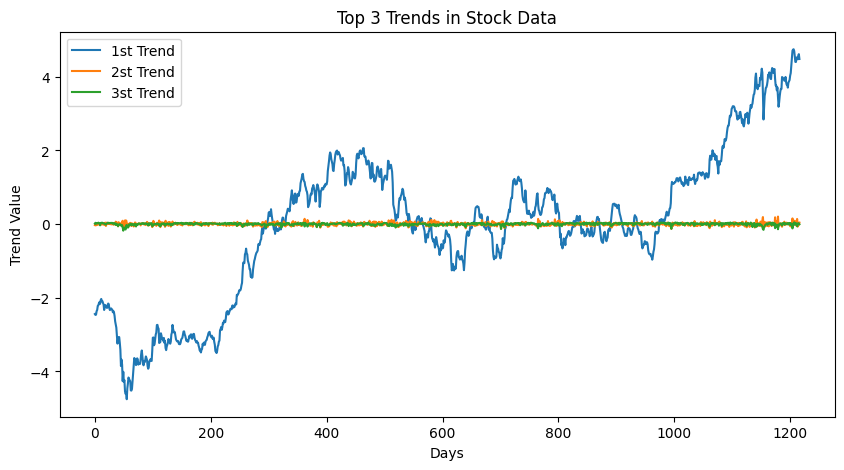

In [223]:
plt.figure(figsize=(10, 5))
for k in range(n_components):
    plt.plot(days, reduced_matrix[k], label=f"{k+1}st Trend")
plt.title(f"Top {n_components} Trends in Stock Data")
plt.xlabel("Days")
plt.ylabel("Trend Value")
plt.legend()
plt.show()

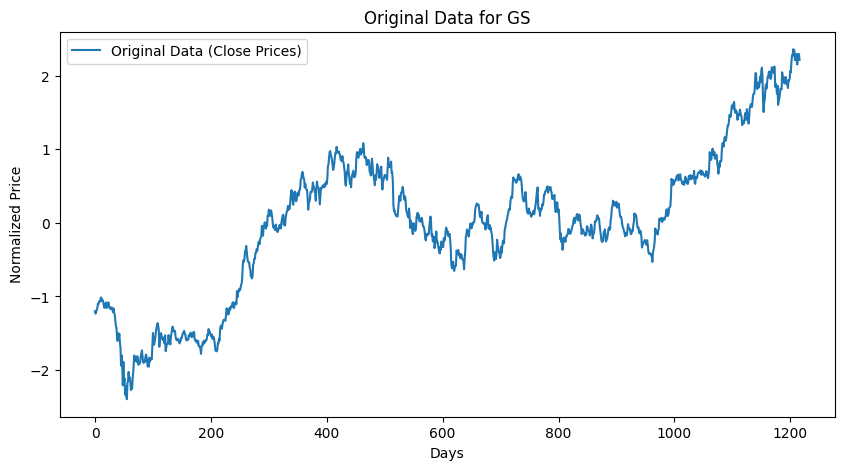

In [224]:
plt.figure(figsize=(10, 5))
plt.plot(orignal[-1], label="Original Data (Close Prices)")
plt.title(f"Original Data for {dataset}")
plt.xlabel("Days")
plt.ylabel("Normalized Price")
plt.legend()
plt.show()

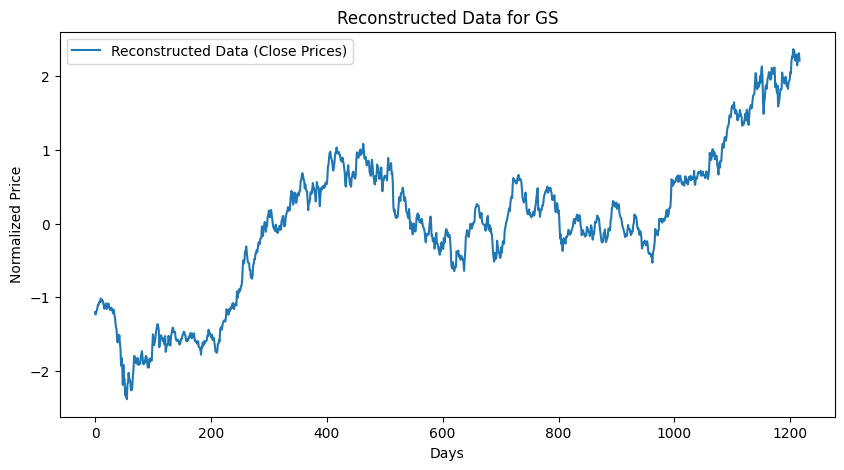

In [225]:
plt.figure(figsize=(10, 5))
plt.plot(reconstructed[-1], label="Reconstructed Data (Close Prices)")
plt.title(f"Reconstructed Data for {dataset}")
plt.xlabel("Days")
plt.ylabel("Normalized Price")
plt.legend()
plt.show()

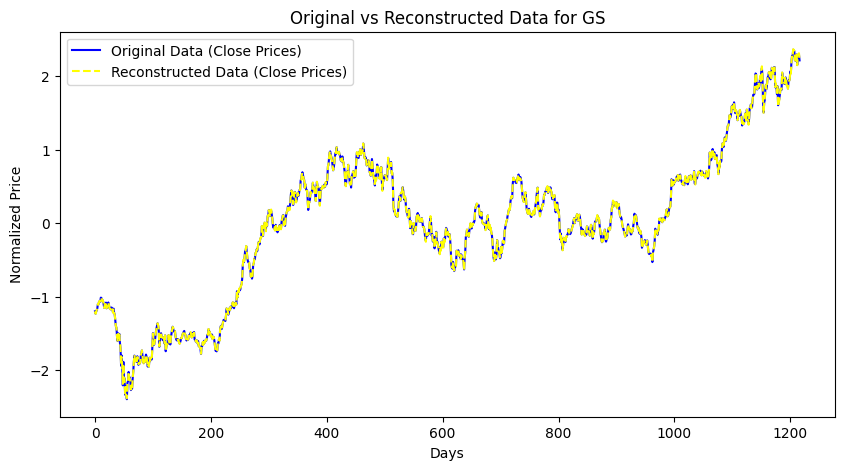

In [226]:
plt.figure(figsize=(10, 5))
plt.plot(orignal[-1], label="Original Data (Close Prices)", color='blue')
plt.plot(reconstructed[-1], label="Reconstructed Data (Close Prices)", linestyle="--", color='yellow')
plt.title(f"Original vs Reconstructed Data for {dataset}")
plt.xlabel("Days")
plt.ylabel("Normalized Price")
plt.legend()
plt.show()

In [227]:
print("Accuracy calculation")
mse = mean_squared_error(orignal.flatten(), reconstructed.flatten())
mae = mean_absolute_error(orignal.flatten(), reconstructed.flatten())
ss_ttl = np.sum((orignal.flatten() - orignal.mean())**2)
ss_rsdual = np.sum((orignal.flatten() - reconstructed.flatten())**2)
r_squared = 1 - (ss_rsdual / ss_ttl)
print(f"Accuracy Metrics:\n- MSE: {mse:.4f}\n- MAE: {mae:.4f}\n- R-squared: {r_squared:.4f}")

Accuracy calculation
Accuracy Metrics:
- MSE: 0.0001
- MAE: 0.0054
- R-squared: 0.9999


In [228]:
print("Target variable creation for analysis")
# Target: 1 if Close > Open, 0 otherwise
target = (data['Close'] > data['Open']).astype(int)
print("Classification performance evaluation after SVD operation")

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
        reduced_matrix.T, target, test_size=0.2, random_state= 29
    )

# Train a simple logistic regression model
model = LogisticRegression(C=1.0, solver='liblinear')  # Fine-tune the regularization strength
model.fit(X_train, y_train.values.ravel())


# Predict on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")
# Calculate F1 Score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

Target variable creation for analysis
Classification performance evaluation after SVD operation
Accuracy Score: 0.9549
F1 Score: 0.9594


Trends forecasted for next 30 days


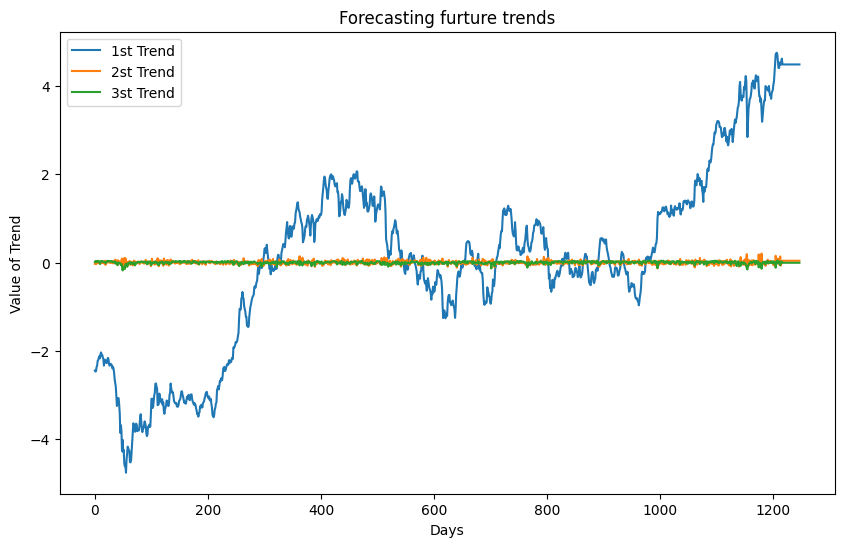

In [229]:
days_forecast = 30  # Days to forecast
print(f"Trends forecasted for next {days_forecast} days")
futre_trnds = np.copy(reduced_matrix)
for k in range(days_forecast):
    trnd_extnson = reduced_matrix[:, -1]  # Extend the last trend
    futre_trnds = np.hstack([futre_trnds, trnd_extnson[:, None]])
dys_futre = np.arange(orignal.shape[1] + days_forecast)
# Visualize forecasted trends
plt.figure(figsize=(10, 6))
for k in range(n_components):
    plt.plot(dys_futre, futre_trnds[k], label=f"{k+1}st Trend")
plt.title("Forecasting furture trends")
plt.xlabel("Days")
plt.ylabel("Value of Trend")
plt.legend()
plt.show()